# PDO and NINO indices
Niño 1+2 (0-10S, 90W-80W):  The Niño 1+2 region is the smallest and eastern-most of the Niño SST regions, and corresponds with the region of coastal South America where El Niño was first recognized by the local populations.  This index tends to have the largest variance of the Niño SST indices.

Niño 3 (5N-5S, 150W-90W):  This region was once the primary focus for monitoring and predicting El Niño, but researchers later learned that the key region for coupled ocean-atmosphere interactions for ENSO lies further west (Trenberth, 1997).  Hence, the Niño 3.4 and ONI became favored for defining El Niño and La Niña events.

Niño 3.4 (5N-5S, 170W-120W):  The  Niño 3.4 anomalies may be thought of as representing the average equatorial SSTs across the Pacific from about the dateline to the South American coast.  The Niño 3.4 index typically uses a 5-month running mean, and El Niño or La  Niña events are defined when the  Niño 3.4 SSTs exceed +/- 0.4C for a period of six months or more.

Niño 4 (5N-5S, 160E-150W): The  Niño 4 index captures SST anomalies in the central equatorial Pacific. This region tends to have less variance than the other Niño regions.

## 0. Set up

### 0.1 Import packages

In [21]:
import cmocean
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import dask
import matplotlib.pyplot as plt
import os
import xesmf as xe
import pop_tools
from eofs.xarray import Eof
import json

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter
from cartopy.util import add_cyclic_point
import matplotlib
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.animation import FFMpegWriter as fw
from matplotlib.animation import PillowWriter as pw

from IPython.utils import io
from os.path import exists

In [4]:
import os
import re

import bottleneck
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
from tqdm import tqdm
import cmocean
from scipy.interpolate import interp1d
import imageio

import pop_tools
# import ocetrac

import dask
import dask_jobqueue
import distributed
import dask.array as da

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import time

### 0.2 Functions

In [6]:
def find_identifier_with_index(prefixes, identifier):
    """
    Find prefixes that contain a specific identifier and their indices.

    Parameters:
        prefixes (list): A list of prefixes to search through.
        identifier (str): The identifier to search for in the prefixes.

    Returns:
        list: A list of tuples containing matching prefixes and their indices.
    """
    matching_prefixes_with_indices = []  # Initialize a list to store matches and their indices

    for index, prefix in enumerate(prefixes):  # Use enumerate to get both index and prefix
        if identifier in prefix:  # Check if the identifier is in the prefix
            matching_prefixes_with_indices.append((prefix, index))  # Add the prefix and index as a tuple

    return matching_prefixes_with_indices  # Return the list of matching prefixes and indices
    
def get_hist_file_paths(var, directory, path_intermed_hist, index):
    attrib_title = path_intermed_hist[index]
    file_paths = []
    for start_year in range(1850, 2010, 10):
        end_year = start_year + 9
        file_path = f'{directory}{attrib_title}.{var}.{start_year}01-{end_year}12.nc'
        file_paths.append(file_path)
    last_file_path = f'{directory}{attrib_title}.{var}.201001-201412.nc'
    file_paths.append(last_file_path)
    return file_paths

def get_fut_file_paths(var, directory, path_intermed_fut, index):
    attrib_title = path_intermed_fut[index]
    file_paths = []
    for start_year in range(2015, 2095, 10):
        end_year = start_year + 9
        file_path = f'{directory}{attrib_title}.{var}.{start_year}01-{end_year}12.nc'
        file_paths.append(file_path)
    last_file_path = f'{directory}{attrib_title}.{var}.209501-210012.nc'
    file_paths.append(last_file_path)
    return file_paths

def file_path_to_var_ds(file_paths):
    var_ds = xr.open_mfdataset(file_paths, 
                                 concat_dim='time', 
                                 combine='nested', 
                                 parallel=True)
    return var_ds

def get_var_paths(directory, var):
    # Prefixes to match for future and historical datasets
    prefixes_to_match_fut = ['b.e21.BSSP370cmip6.', 'b.e21.BSSP370smbb.']
    prefixes_to_match_hist = ['b.e21.BHISTcmip6.', 'b.e21.BHISTsmbb.']
        
    # Sets to store unique prefixes for future and historical filenames
    prefixes_fut = list()
    prefixes_hist = list()
        
    # Iterate through files in the directory
    for filename in os.listdir(directory):
        # Check and add prefixes for future scenario files
        if any(filename.startswith(prefix) for prefix in prefixes_to_match_fut) and filename.endswith('.nc'):
            prefixes_fut.append(filename.rsplit('.', 3)[0])
            
        # Check and add prefixes for historical scenario files
        if any(filename.startswith(prefix) for prefix in prefixes_to_match_hist) and filename.endswith('.nc'):
            prefixes_hist.append(filename.rsplit('.', 3)[0])
        
    prefixes_hist_set = set(prefixes_hist)
    sorted_unique_list_hist = sorted(prefixes_hist_set)
    
    prefixes_fut_set = set(prefixes_fut)
    sorted_unique_list_fut = sorted(prefixes_fut_set)
    
    path_intermed_fut = sorted_unique_list_fut
    path_intermed_hist = sorted_unique_list_hist

    return path_intermed_hist, path_intermed_fut

def get_ds_var(directory, var, comp, index_hist):
    path_intermed_hist, path_intermed_fut = get_var_paths(directory, var)
    filename_identifier = '.'.join(path_intermed_hist[index_hist].rsplit('.', 5)[1:4])
    index_fut = find_identifier_with_index(path_intermed_hist, filename_identifier)[0][1]
    hist_file_paths = get_hist_file_paths(var,directory, path_intermed_hist, index_hist)
    fut_file_paths = get_fut_file_paths(var, directory, path_intermed_fut, index_fut)
    ds_var_fut = file_path_to_var_ds(fut_file_paths)
    ds_var_hist = file_path_to_var_ds(hist_file_paths)
    return ds_var_hist, ds_var_fut

In [7]:
def calculate_anomalies_trend_features(ds):
    sst = ds
    dyr = ds.time.dt.year + ds.time.dt.month/12
    # Our 6 coefficient model is composed of the mean, trend, annual sine and cosine harmonics, & semi-annual sine and cosine harmonics
    model = np.array([np.ones(len(dyr))] + [dyr-np.mean(dyr)] + [np.sin(2*np.pi*dyr)] + [np.cos(2*np.pi*dyr)] + [np.sin(4*np.pi*dyr)] + [np.cos(4*np.pi*dyr)])
    
    # Take the pseudo-inverse of model to 'solve' least-squares problem
    pmodel = np.linalg.pinv(model)
    
    # Convert model and pmodel to xaray DataArray
    model_da = xr.DataArray(model.T, dims=['time','coeff'], coords={'time':sst.time.values, 'coeff':np.arange(1,7,1)}) 
    pmodel_da = xr.DataArray(pmodel.T, dims=['coeff','time'], coords={'coeff':np.arange(1,7,1), 'time':sst.time.values})  
    
    # resulting coefficients of the model
    sst_mod = xr.DataArray(pmodel_da.dot(sst), dims=['coeff','lat','lon'], coords={'coeff':np.arange(1,7,1), 'lat':sst.lat.values, 'lon':sst.lon.values})
    
    # Construct mean, trend, and seasonal cycle
    mean = model_da[:,0].dot(sst_mod[0,:,:])
    trend = model_da[:,1].dot(sst_mod[1,:,:])
    seas = model_da[:,2:].dot(sst_mod[2:,:,:])
    
    # compute anomalies by removing all  the model coefficients 
    ssta_notrend = sst-model_da.dot(sst_mod)
    
    # Use the 90th percentile as a threshold and find anomalies that exceed it. 
    if ssta_notrend.chunks:
        ssta_notrend = ssta_notrend.chunk({'time': -1})
    
    threshold = ssta_notrend.quantile(.9, dim=('time'))
    features_notrend = ssta_notrend.where(ssta_notrend>=threshold, other=np.nan)
    return mean, trend, seas, features_notrend, ssta_notrend

In [8]:
def setup_axes(ax):
    ax.add_feature(cfeature.LAND, facecolor='white', zorder=2)
    ax.coastlines(resolution='110m', color='black', lw=2)
    ax.set_ylabel('latitude')
    ax.set_xlabel('longitude')


def lons_to_360(data, coord='lon'):
    """ Converts longitude coordinates from (-180, 180) to (0, 360)."""
    data.coords[coord] = (360 + (data.coords[coord] % 360)) % 360
    data = data.sortby(data[coord])
    return data


def remove_trend(da, dim, deg=1):
    # detrend along a single dimension
    # return polyfit coefficients and detrended da
    p = da.polyfit(dim=dim, deg=deg, skipna=True)
    coord = da.coords[dim]
    fit = xr.polyval(coord, p.polyfit_coefficients)
    return da - fit


def get_anoms(da):
    clim = da.groupby('time.month').mean('time')
    da_noclim = da.groupby('time.month') - clim
    anoms = remove_trend(da_noclim, dim='time')
    return anoms


def regrid_SMYLE(ds, glat=1, glon=1):
    """
    Inputs:
        ds: xr.DataArray with coordinates that include TLAT and TLONG
    Returns:
        Regridded xr.DataArray with coordinates lat and lon
    """
    ds = ds.rename(({'TLONG': 'lon', 'TLAT': 'lat'}))
    ds_out = xe.util.grid_global(glon, glat)
    regridder = xe.Regridder(ds, ds_out, 'bilinear', periodic=True)
    regridded = regridder(ds)
    new_coords = regridded.assign_coords({'y': regridded.lat[:, 0].values, 'x': regridded.lon[0].values})
    return new_coords.drop_vars(['lat', 'lon']).rename({'x': 'lon', 'y': 'lat'})

In [9]:
def calculate_deseasonalized_only(ds):
    """
    Removes mean and annual/semiannual harmonics only, retaining the trend.
    Matches the LENS 'noseas' (seasonality-removal-only) convention.
    """
    sst = ds
    dyr = ds.time.dt.year + ds.time.dt.month / 12

    # 4-coefficient model: mean, annual sin/cos, semiannual sin/cos (NO trend term)
    model = np.array(
        [np.ones(len(dyr))] +
        [np.sin(2*np.pi*dyr)] +
        [np.cos(2*np.pi*dyr)] +
        [np.sin(4*np.pi*dyr)] +
        [np.cos(4*np.pi*dyr)]
    )

    pmodel = np.linalg.pinv(model)

    model_da = xr.DataArray(model.T, dims=['time','coeff'],
                             coords={'time': sst.time.values, 'coeff': np.arange(1,6,1)})
    pmodel_da = xr.DataArray(pmodel.T, dims=['coeff','time'],
                              coords={'coeff': np.arange(1,6,1), 'time': sst.time.values})

    sst_mod = xr.DataArray(pmodel_da.dot(sst), dims=['coeff','lat','lon'],
                            coords={'coeff': np.arange(1,6,1), 'lat': sst.lat.values, 'lon': sst.lon.values})

    # Deseasonalized anomaly = observed minus (mean + seasonal harmonics), trend RETAINED
    seasonal_fit = model_da.dot(sst_mod)
    ssta_deseasonalized_only = sst - seasonal_fit

    return ssta_deseasonalized_only

In [10]:
def project_onto_pattern(sst_anom, pattern):
    sst_anom, pattern = xr.align(sst_anom, pattern, join='inner')
    return (sst_anom * pattern).sum(dim=('lat','lon')) / (pattern**2).sum(dim=('lat','lon'))

In [11]:
def load_lens_sst_full_basin(member_id):
    directory = '/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/month_1/SST/'
    ds_hist, ds_fut = get_ds_var(directory, 'SST', 'atm', member_id)
    hist = ds_hist.SST.sel(time=slice('1979-01-01','2015-01-01'))
    fut = ds_fut.SST.sel(time=slice('2015-02-01','2020-12-01'))
    combined = xr.concat([hist, fut], dim='time').compute()
    return combined.where(combined != 0, np.nan)

In [14]:
def calc_frac_overlap(one_obj, mask):
    one_obj_binary = xr.where(one_obj > 0, 1., 0)
    overlap = one_obj_binary + mask
    overlap_only = xr.where(overlap > 1, 1., 0)
    overlap_frac = overlap_only.sum(dim=('lat','lon')) / mask.sum()
    if overlap_frac.size > 0 and overlap_frac.notnull().any():
        return overlap_frac.max().item()
    return 0.0

## Load data

In [45]:
# Domains
nino34_lat, nino34_lon = slice(-5, 5), slice(190, 240)      # 5N-5S, 170W-120W
pdo_lat, pdo_lon = slice(20, 65), slice(120, 260)            # 20-65N, full basin

In [73]:
fosi_blobs = xr.open_dataset('fosi_blobs_r2.nc').labels
object_id = 94.0
blob_times = fosi_blobs.time.where((fosi_blobs == object_id).any(dim=('lat','lon')), drop=True)

print(f"n_months: {len(blob_times)}")  # should print 20

n_months: 20


In [41]:
#### CESM LENS2
var = 'SST'
comp = 'atm'
directory = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'
ens_memb_index = 0
ds_var_hist_SST, ds_var_fut_SST = get_ds_var(directory, 'SST','atm', ens_memb_index) 

# selecting our observational time period overlap with ERA5 (1979 to 2022)
CESMLENS_SST_hist_time_slice = ds_var_hist_SST.SST.sel(time=slice('1979-01-01', '2015-01-01'))
    
CESMLENS_SST_fut_time_slice = ds_var_fut_SST.SST.sel(time=slice('2015-02-01', '2020-12-01'))

CESMLENS_SST_ds = xr.concat([CESMLENS_SST_hist_time_slice, CESMLENS_SST_fut_time_slice], dim='time')
CESMLENS_SST = CESMLENS_SST_ds.compute()

In [40]:
#### FOSI
firstyear = 1979
lastyear = 2020
field = 'TEMP'

# Mask the Arctic, the Baltic Sea, the Red Sea, and the Black Sea
grid = pop_tools.get_grid('POP_gx1v7')
mask = xr.where((grid['REGION_MASK']>0) & (grid['REGION_MASK']<9), 1, np.nan)

fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
ds_smyle_fosi = xr.open_dataset(fpath+fname)[field].isel(z_t=0)

fosi_montime_vals = [cftime.DatetimeNoLeap(1958+year, 1+month, 15) for year in range(63) for month in range(12)]
ds_smyle_fosi['time'] = fosi_montime_vals
fosi_temp = ds_smyle_fosi[ds_smyle_fosi.time['time.year'].isin(list(range(firstyear, lastyear+1)))].where(mask==1, np.nan)

fosi_anom_1deg_wzeros = regrid_SMYLE(ds_smyle_fosi)
fosi_anom_1deg = fosi_anom_1deg_wzeros.where(fosi_anom_1deg_wzeros!=0, np.nan)

regridder = xe.Regridder(fosi_anom_1deg.sel(time=slice('1979-01-01','2020-12-01')), CESMLENS_SST[:,:,:], 'nearest_s2d', periodic=True)
regridded = regridder(fosi_anom_1deg.sel(time=slice('1979-01-01','2020-12-01')))
# regridded[4,:,:].plot.contourf(levels=25)

NameError: name 'CESMLENS_SST' is not defined

In [43]:
dyr = regridded.time.dt.year + regridded.time.dt.month/12

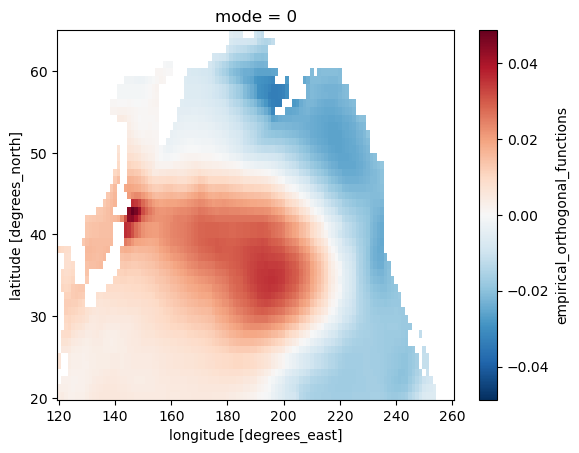

In [46]:
# FOSI: deseasonalized-only (noseas) SST, FULL basin (not NEP-cropped)
sst_fosi_noseas_full = calculate_deseasonalized_only(regridded)  # function from earlier this session

nino34_fosi_region = sst_fosi_noseas_full.sel(lat=nino34_lat, lon=nino34_lon)
pdo_fosi_region = sst_fosi_noseas_full.sel(lat=pdo_lat, lon=pdo_lon)

# Niño3.4: simple area-weighted mean, no EOF needed
weights_nino = np.cos(np.deg2rad(nino34_fosi_region.lat))
nino34_fosi = (nino34_fosi_region * weights_nino).mean(dim=('lat','lon')) / weights_nino.mean()
nino34_fosi_norm = nino34_fosi / float(nino34_fosi.std())

# PDO: EOF-based, full basin
solver = Eof(pdo_fosi_region)
eof1_pdo_full = solver.eofs(neofs=1).isel(mode=0)
eof1_pdo_full.plot()  # CHECK SIGN before proceeding

In [47]:
eof1_pdo_full_fixed = -eof1_pdo_full

pdo_fosi = project_onto_pattern(pdo_fosi_region, eof1_pdo_full_fixed)
pdo_std = float(pdo_fosi.std())
pdo_fosi_norm = pdo_fosi / pdo_std

print(f"Niño3.4 during Blob: mean={float(nino34_fosi_norm.sel(time=blob_times).mean()):.2f}, "
      f"max={float(nino34_fosi_norm.sel(time=blob_times).max()):.2f}")
print(f"PDO during Blob: mean={float(pdo_fosi_norm.sel(time=blob_times).mean()):.2f}, "
      f"max={float(pdo_fosi_norm.sel(time=blob_times).max()):.2f}")

Niño3.4 during Blob: mean=1.13, max=3.08
PDO during Blob: mean=1.02, max=1.85


In [2]:
## Run if running for all ensemble members
# nino34_lens = {}
# pdo_lens = {}

# for member_id in range(100):
#     print(member_id)
#     sst_member = load_lens_sst_full_basin(member_id)
#     sst_member_noseas = calculate_deseasonalized_only(sst_member)

#     nino_region = sst_member_noseas.sel(lat=nino34_lat, lon=nino34_lon)
#     w = np.cos(np.deg2rad(nino_region.lat))
#     nino34_lens[member_id] = ((nino_region * w).mean(dim=('lat','lon')) / w.mean()) / float(nino34_fosi.std())

#     pdo_region = sst_member_noseas.sel(lat=pdo_lat, lon=pdo_lon)
#     pdo_lens[member_id] = project_onto_pattern(pdo_region, eof1_pdo_full_fixed) / pdo_std

#     if member_id % 10 == 0:
#         print(f"Member {member_id} done")

# nino34_lens_all = xr.concat(list(nino34_lens.values()), dim='member').assign_coords(member=np.arange(100))
# pdo_lens_all = xr.concat(list(pdo_lens.values()), dim='member').assign_coords(member=np.arange(100))

# print(f"Total time: {time.time()-t0:.1f}s")
# print(f"Niño3.4 LENS range: {float(nino34_lens_all.min()):.2f} to {float(nino34_lens_all.max()):.2f}")
# print(f"PDO LENS range: {float(pdo_lens_all.min()):.2f} to {float(pdo_lens_all.max()):.2f}")

# nino34_lens_all.to_netcdf('/glade/derecho/scratch/cassiacai/nino34_lens_full_basin.nc')
# pdo_lens_all.to_netcdf('/glade/derecho/scratch/cassiacai/pdo_lens_full_basin.nc')
# print("Saved.")

## Examining

In [13]:
nino34_lens_all = xr.open_dataset('/glade/derecho/scratch/cassiacai/nino34_lens_full_basin.nc')
pdo_lens_all = xr.open_dataset('/glade/derecho/scratch/cassiacai/pdo_lens_full_basin.nc')

In [12]:
base_paths = {
    'linear': '/glade/work/cmendiola/data_conv_lin_trend',
    'quadratic': '/glade/work/cmendiola/data_quad_trend',
    'ensmean': '/glade/work/cmendiola/data_ens_mean',
    'noseas': '/glade/work/cmendiola/data_rm_seasonalcycle_mean',
}

RADIUS_INDEX_FOR_2DEG = 1  # confirmed: index 1 = 2° structuring element, consistent across all four methods

# SSTa variable names per method (confirmed this session)
ssta_varnames = {
    'linear': '__xarray_dataarray_variable__',
    'quadratic': '__xarray_dataarray_variable__',
    'ensmean': 'SST',
    'noseas': '__xarray_dataarray_variable__',
}

da_mhwobj_labels_by_method = {}
ssta_notrend_by_method = {}

for method, base_path in base_paths.items():
    mhwobj_paths = [f'{base_path}/ens_{i}_mhwobj.nc' for i in range(100)]
    ssta_paths = [f'{base_path}/ens_{i}_ssta.nc' for i in range(100)]

    da_mhwobj = xr.open_mfdataset(mhwobj_paths, combine='nested', concat_dim='ensemble_member')
    da_mhwobj_labels_by_method[method] = da_mhwobj.labels.sel(radius=RADIUS_INDEX_FOR_2DEG).sel(time=slice('1979-01','2020-12')).compute()

    ssta_notrend_by_method[method] = xr.open_mfdataset(ssta_paths, combine='nested', concat_dim='ensemble_member').compute()

print("All four methods loaded.")
print({m: da_mhwobj_labels_by_method[m].sizes for m in base_paths})

All four methods loaded.
{'linear': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81}), 'quadratic': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81}), 'ensmean': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81}), 'noseas': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81})}


In [17]:
# Canonical footprint (mask_3) - used throughout for Blob-analog identification and area-averaging
mask_3 = xr.open_dataset('mean_mask_3.nc').mhw_obj
mask_3_binary = xr.where(mask_3 > 0.1, 1, 0)

In [18]:
R = 6371.0
grid_ref = da_mhwobj_labels_by_method['linear']
dlat = np.deg2rad(np.mean(np.diff(grid_ref.lat.values)))
dlon = np.deg2rad(np.mean(np.diff(grid_ref.lon.values)))
cell_area = (R**2) * dlat * dlon * np.cos(np.deg2rad(grid_ref.lat))
cell_area_da = xr.DataArray(cell_area.values, coords={'lat': grid_ref.lat}, dims='lat')

print(f"Equatorial gridcell area check: {float(cell_area_da.sel(lat=grid_ref.lat.values[len(grid_ref.lat)//2])):.1f} km²")

Equatorial gridcell area check: 11881.4 km²


In [22]:
# Blob-analog IDs (50% overlap threshold, index 4 of thresholds array)
thresholds = np.arange(0.1, 0.81, 0.1)

with open('object_id_ls_greenmask_linear_corrected.json', 'r') as f:
    linear_all_thresholds = json.load(f)
with open('object_id_ls_greenmask_ensmean_corrected.json', 'r') as f:
    ensmean_all_thresholds = json.load(f)
with open('object_id_ls_greenmask_quadratic_corrected.json', 'r') as f:
    quadratic_all_thresholds = json.load(f)
with open('object_id_ls_greenmask_noseas_corrected.json', 'r') as f:
    noseas_all_thresholds = json.load(f)
# adjust filenames/paths for quadratic and noseas to match wherever you saved those corrected versions

blob_analog_ids = {
    'linear': linear_all_thresholds[4],
    'ensmean': ensmean_all_thresholds[4],
    'quadratic': ensmean_all_thresholds[4],
    'noseas': ensmean_all_thresholds[4],
}

In [24]:
# FOSI Blob (Label 94, confirmed 20-month window: May 2014 - Dec 2015)
fosi_blobs = xr.open_dataset('fosi_blobs_r2.nc').labels
object_id = 94.0
blob_times = fosi_blobs.time.where((fosi_blobs == object_id).any(dim=('lat','lon')), drop=True)

regridded_ssta_no_trend_NEP = xr.open_dataset('/glade/derecho/scratch/cassiacai/regridded_ssta_no_trend_NEP.nc')

print(regridded_ssta_no_trend_NEP.sel(time='2015-07').max().values)
print(f"n_months in blob_times: {len(blob_times)}")  # should be 20

<bound method Mapping.values of <xarray.Dataset> Size: 12B
Dimensions:                        ()
Coordinates:
    z_t                            float32 4B ...
Data variables:
    __xarray_dataarray_variable__  float64 8B 2.345>
n_months in blob_times: 20


In [25]:
nino34_lens_all_da = nino34_lens_all['__xarray_dataarray_variable__']
pdo_lens_all_da = pdo_lens_all['__xarray_dataarray_variable__']  # adjust if the print above shows a different name

In [35]:
# # COMPUTING Per-analog Niño3.4 and PDO stats
# analog_climate_stats = {}
# labels_full = da_mhwobj_labels_by_method['linear']

# for member_id in range(100):
#     member_labels = labels_full.isel(ensemble_member=member_id)
#     member_nino = nino34_lens_all_da.sel(member=member_id)
#     member_pdo = pdo_lens_all_da.sel(member=member_id)

#     for analog_id in blob_analog_ids['linear'][member_id]:
#         mask = (member_labels == analog_id)
#         times_present = member_labels.time.where(mask.any(dim=('lat','lon')), drop=True)
#         if len(times_present) == 0:
#             continue

#         nino_vals = member_nino.sel(time=times_present)
#         pdo_vals = member_pdo.sel(time=times_present)

#         analog_climate_stats[(member_id, analog_id)] = {
#             'nino34_mean': float(nino_vals.mean()),
#             'nino34_max': float(nino_vals.max()),
#             'pdo_mean': float(pdo_vals.mean()),
#             'pdo_max': float(pdo_vals.max()),
#         }

# print(f"Climate context computed for {len(analog_climate_stats)} analogs")

Climate context computed for 331 analogs


In [53]:
blob_climate = {
    'nino34_mean': float(nino34_fosi_norm.sel(time=blob_times).mean()),
    'nino34_max': float(nino34_fosi_norm.sel(time=blob_times).max()),
    'pdo_mean': float(pdo_fosi_norm.sel(time=blob_times).mean()),
    'pdo_max': float(pdo_fosi_norm.sel(time=blob_times).max()),
}
print(blob_climate)

{'nino34_mean': 1.1281033521296626, 'nino34_max': 3.0774558632413305, 'pdo_mean': 1.0245222060799457, 'pdo_max': 1.8462614767620456}


In [35]:
climate_bundle = {
    'analog_climate_stats': analog_climate_stats,
    'blob_climate': blob_climate,
}

with open('/glade/derecho/scratch/cassiacai/section_3_2_climate_data.pkl', 'wb') as f:
    pickle.dump(climate_bundle, f)

print("Saved section_3_2_climate_data.pkl")
print(f"  - {len(analog_climate_stats)} analogs with climate context")

Saved section_3_2_climate_data.pkl
  - 331 analogs with climate context


In [36]:
with open('/glade/derecho/scratch/cassiacai/section_3_2_analog_data.pkl', 'rb') as f:
    physical_bundle = pickle.load(f)

with open('/glade/derecho/scratch/cassiacai/section_3_2_climate_data.pkl', 'rb') as f:
    climate_bundle = pickle.load(f)

all_analog_characteristics = physical_bundle['all_analog_characteristics']
blob_fosi_characteristics = physical_bundle['blob_fosi_characteristics']
analog_climate_stats = climate_bundle['analog_climate_stats']
blob_climate = climate_bundle['blob_climate']

print(f"Physical: {len(all_analog_characteristics)} analogs")
print(f"Climate: {len(analog_climate_stats)} analogs")

Physical: 331 analogs
Climate: 331 analogs


In [37]:
# Find analogs that are EXTREME in physical characteristics (like the Blob)
# but ALSO have unremarkable PDO/ENSO (matching the Blob's own pattern)
extreme_analogs = []
for key in all_analog_characteristics:
    char = all_analog_characteristics[key]
    climate = analog_climate_stats.get(key)
    if climate is None:
        continue
    # "Extreme" defined loosely as: duration/extent/intensity/MLD all above median
    if (char['duration'] > np.median([c['duration'] for c in all_analog_characteristics.values()]) and
        char['extent_max'] > np.median([c['extent_max'] for c in all_analog_characteristics.values()]) and
        climate['pdo_mean'] < blob_climate['pdo_mean']):  # PDO weaker than Blob's, like we're asking about
        extreme_analogs.append((key, char, climate))

print(f"Found {len(extreme_analogs)} analogs matching 'extreme physically, unremarkable PDO' pattern")
for key, char, climate in extreme_analogs[:5]:
    print(key, f"duration={char['duration']}, extent_max={char['extent_max']:.1e}, "
               f"intensity_max={char['intensity_max']:.2f}, pdo_mean={climate['pdo_mean']:.2f}")

Found 45 analogs matching 'extreme physically, unremarkable PDO' pattern
(1, 75.0) duration=30, extent_max=3.5e+07, intensity_max=7.41, pdo_mean=0.25
(3, 67.0) duration=21, extent_max=2.5e+07, intensity_max=3.97, pdo_mean=0.95
(4, 34.0) duration=24, extent_max=2.1e+07, intensity_max=3.66, pdo_mean=-0.34
(4, 50.0) duration=24, extent_max=1.9e+07, intensity_max=3.32, pdo_mean=0.39
(8, 44.0) duration=25, extent_max=2.0e+07, intensity_max=2.92, pdo_mean=0.91


In [38]:
key = (1, 75.0)
print("Physical characteristics:", all_analog_characteristics[key])
print("Climate context:", analog_climate_stats[key])

# Where does it fall in the return-period distributions?
extent_all = np.array([c['extent_max'] for c in all_analog_characteristics.values()])
intensity_all = np.array([c['intensity_max'] for c in all_analog_characteristics.values()])
print(f"Extent percentile: {100*np.mean(extent_all <= all_analog_characteristics[key]['extent_max']):.1f}%")
print(f"Intensity percentile: {100*np.mean(intensity_all <= all_analog_characteristics[key]['intensity_max']):.1f}%")

Physical characteristics: {'duration': 30, 'intensity_mean': 1.3235473982997348, 'intensity_max': 7.408280314647925, 'extent_mean': 18211785.077315435, 'extent_max': 34806259.57432512, 'extent_cumulative': 546353552.319463, 'mld_mean': 64.25398411279292, 'mld_max': 235.94784545898438, 'mld_p90': 115.35419998168945}
Climate context: {'nino34_mean': 1.3737765103958544, 'nino34_max': 3.913100408086391, 'pdo_mean': 0.2505819770540517, 'pdo_max': 2.598085764953028}
Extent percentile: 100.0%
Intensity percentile: 95.2%


In [39]:
common_keys = [k for k in all_analog_characteristics if k in analog_climate_stats]
pdo_vals = np.array([analog_climate_stats[k]['pdo_mean'] for k in common_keys])
extent_vals = np.array([all_analog_characteristics[k]['extent_max'] for k in common_keys])
duration_vals = np.array([all_analog_characteristics[k]['duration'] for k in common_keys])
intensity_vals = np.array([all_analog_characteristics[k]['intensity_max'] for k in common_keys])

print(f"Correlation (PDO vs extent): {np.corrcoef(pdo_vals, extent_vals)[0,1]:.3f}")
print(f"Correlation (PDO vs duration): {np.corrcoef(pdo_vals, duration_vals)[0,1]:.3f}")
print(f"Correlation (PDO vs intensity): {np.corrcoef(pdo_vals, intensity_vals)[0,1]:.3f}")

Correlation (PDO vs extent): -0.177
Correlation (PDO vs duration): -0.186
Correlation (PDO vs intensity): 0.098


In [58]:
member_id, analog_id = 1, 75.0

labels_full = da_mhwobj_labels_by_method['linear']
ssta_full = ssta_notrend_by_method['linear']['__xarray_dataarray_variable__']

member_labels = labels_full.isel(ensemble_member=member_id)
member_ssta = ssta_full.isel(ensemble_member=member_id)

mask = (member_labels == analog_id)
times_present = member_labels.time.where(mask.any(dim=('lat','lon')), drop=True)

print(f"Duration: {len(times_present)} months")
print(f"Start: {str(times_present.values[0])[:10]}, End: {str(times_present.values[-1])[:10]}")

# Find peak-intensity month within this event, plot it
mask_trimmed = mask.sel(time=times_present)
ssta_masked = member_ssta.sel(time=times_present).where(mask_trimmed)

# Timestep of maximum SSTa
peak_idx = int(ssta_masked.max(dim=('lat','lon')).argmax('time').values)
peak_time = times_present.values[peak_idx]

ssta_at_peak = member_ssta.sel(time=peak_time)
mask_at_peak = mask.sel(time=peak_time).astype(int)

Duration: 30 months
Start: 2004-02-01, End: 2006-07-01


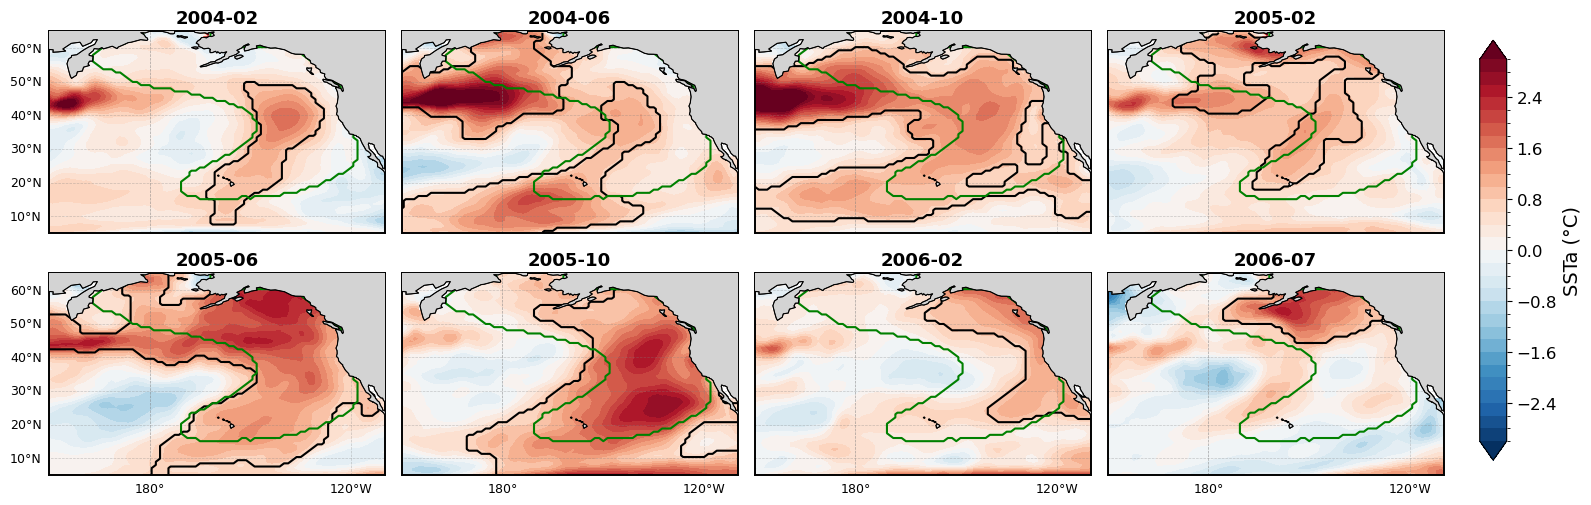

In [66]:
n_show = min(8, len(times_present))
sample_idx = np.linspace(0, len(times_present)-1, n_show).astype(int)
sample_times = times_present.values[sample_idx]

fig, axes = plt.subplots(2, 4, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
axes = axes.flatten()

for i, (ax, t) in enumerate(zip(axes, sample_times)):
    ssta_t = member_ssta.sel(time=t)
    mask_t = mask.sel(time=t).astype(int)

    im = ssta_t.plot.contourf(
        ax=ax, transform=ccrs.PlateCarree(),
        levels=np.linspace(-3, 3, 31), cmap='RdBu_r', add_colorbar=False, extend='both'
    )

    ax.contour(mask_t.lon, mask_t.lat, mask_t, levels=[0.5], colors='black', linewidths=1.5,
               transform=ccrs.PlateCarree(), zorder=10)
    ax.contour(mask_3_binary.lon, mask_3_binary.lat, mask_3_binary, levels=[0.5], colors='green',
               linewidths=1.5, transform=ccrs.PlateCarree(), zorder=11)

    ax.add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black', linewidth=0.5, zorder=20)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=21)

    ax.set_title(str(t)[:7], fontsize=13, fontweight='bold')

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)

    ax.set_extent([150, 250, 5, 65], crs=ccrs.PlateCarree())

    # Gridlines with lat/lon labels
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.4, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 4 == 0)      # only leftmost column
    gl.bottom_labels = (i >= 4)         # only bottom row
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('SSTa (°C)', fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.subplots_adjust(hspace=0.1, wspace=0.05)
plt.savefig('Figure_extreme_analog_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

In [72]:
member_id, analog_id = 1, 75.0
member_labels = da_mhwobj_labels_by_method['linear'].isel(ensemble_member=member_id)
mask = (member_labels == analog_id)
times_present = member_labels.time.where(mask.any(dim=('lat','lon')), drop=True)

member_ssta = ssta_notrend_by_method['linear']['__xarray_dataarray_variable__'].isel(ensemble_member=member_id)
mask_trimmed = mask.sel(time=times_present)
ssta_masked = member_ssta.sel(time=times_present).where(mask_trimmed)

max_per_time = ssta_masked.max(dim=('lat','lon'))
peak_time = max_per_time.time.values[int(max_per_time.argmax('time').values)]  # pulled directly, correct type guaranteed

print(f"Peak time: {peak_time}")

Peak time: 2005-03-01 00:00:00


In [73]:
ssta_at_peak = member_ssta.sel(time=peak_time)
mask_at_peak = mask.sel(time=peak_time).astype(int)

ssta_masked_peak = ssta_at_peak.where(mask_at_peak==1)
max_loc = ssta_masked_peak.where(ssta_masked_peak == ssta_masked_peak.max(), drop=True)

print("Location of max value (lat, lon):", float(max_loc.lat.values[0]), float(max_loc.lon.values[0]))
print("Max value:", float(max_loc.values.flatten()[0]))

Location of max value (lat, lon): 62.67015706806283 196.25
Max value: 7.408280314647925


In [55]:
extent_mean_values = np.array([c['extent_mean'] for c in all_analog_characteristics.values()])
intensity_mean_values = np.array([c['intensity_mean'] for c in all_analog_characteristics.values()])
mld_mean_values = np.array([c['mld_mean'] for c in all_analog_characteristics.values()])

N_years = 100 * 42
n = len(extent_mean_values)

for name, values, blob_val in [
    ('extent_mean', extent_mean_values, blob_fosi_characteristics['extent_mean']),
    ('intensity_mean', intensity_mean_values, blob_fosi_characteristics['intensity_mean']),
    ('mld_mean', mld_mean_values, blob_fosi_characteristics['mld_mean']),
]:
    p = np.mean(values >= blob_val)
    rp = N_years / (n * p) if p > 0 else np.inf
    print(f"{name}: {100*p:.1f}% of analogs ≥ Blob's value, return period = {rp:.1f} years")

extent_mean: 20.5% of analogs ≥ Blob's value, return period = 61.8 years
intensity_mean: 97.9% of analogs ≥ Blob's value, return period = 13.0 years
mld_mean: 47.7% of analogs ≥ Blob's value, return period = 26.6 years


In [56]:
for name, char in [('duration', 'duration'), ('intensity_max', 'intensity_max'),
                     ('extent_max', 'extent_max'), ('mld_max', 'mld_max')]:
    values = np.array([c[char] for c in all_analog_characteristics.values() if char in c])
    blob_val = blob_fosi_characteristics[char]
    p = np.mean(values >= blob_val)
    rp = N_years / (n * p) if p > 0 else np.inf
    print(f"{name}: {100*p:.1f}% of analogs ≥ Blob's value, return period = {rp:.1f} years")

duration: 19.3% of analogs ≥ Blob's value, return period = 65.6 years
intensity_max: 91.5% of analogs ≥ Blob's value, return period = 13.9 years
extent_max: 12.7% of analogs ≥ Blob's value, return period = 100.0 years
mld_max: 17.2% of analogs ≥ Blob's value, return period = 73.7 years


In [47]:
max_per_time = ssta_masked.max(dim=('lat','lon'))
print("Max per time (all values):")
print(max_per_time.values)

peak_idx_check = int(max_per_time.argmax('time').values)
print(f"\npeak_idx: {peak_idx_check}")
print(f"Time at peak_idx: {max_per_time.time.values[peak_idx_check]}")
print(f"Value at peak_idx: {float(max_per_time.isel(time=peak_idx_check))}")

print(f"\ntimes_present length: {len(times_present)}")
print(f"max_per_time length: {len(max_per_time)}")

Max per time (all values):
[1.71429353 2.07272001 3.51211708 4.36190421 4.20955462 3.68766799
 3.29608206 4.3769079  4.36166808 2.12273245 2.387201   2.75507406
 6.25407605 7.40828031 2.01762532 2.52668974 2.580763   2.84893687
 2.75719375 3.7412302  2.77551941 2.94154646 3.32105893 2.71535419
 1.96371727 2.29072065 2.54064857 2.11121583 1.45428859 2.53286537]

peak_idx: 13
Time at peak_idx: 2005-03-01 00:00:00
Value at peak_idx: 7.408280314647925

times_present length: 30
max_per_time length: 30


In [49]:
# Add 90th percentile to per-analog Niño3.4/PDO stats
analog_climate_stats = {}
labels_full = da_mhwobj_labels_by_method['linear']

for member_id in range(100):
    member_labels = labels_full.isel(ensemble_member=member_id)
    member_nino = nino34_lens_all.sel(member=member_id)
    member_pdo = pdo_lens_all.sel(member=member_id)

    for analog_id in blob_analog_ids['linear'][member_id]:
        mask = (member_labels == analog_id)
        times_present = member_labels.time.where(mask.any(dim=('lat','lon')), drop=True)
        if len(times_present) == 0:
            continue

        nino_vals = member_nino.sel(time=times_present)
        pdo_vals = member_pdo.sel(time=times_present)

        analog_climate_stats[(member_id, analog_id)] = {
            'nino34_mean': float(nino_vals.mean()),
            'nino34_max': float(nino_vals.max()),
            'nino34_p90': float(nino_vals.quantile(0.9)),
            'pdo_mean': float(pdo_vals.mean()),
            'pdo_max': float(pdo_vals.max()),
            'pdo_p90': float(pdo_vals.quantile(0.9)),
        }

print(f"Climate context (with p90) computed for {len(analog_climate_stats)} analogs")

Climate context (with p90) computed for 331 analogs


In [50]:
# FOSI Blob's p90 values
nino34_during_blob = nino34_fosi_norm.sel(time=blob_times)
pdo_during_blob = pdo_fosi_norm.sel(time=blob_times)

blob_climate = {
    'nino34_mean': float(nino34_during_blob.mean()),
    'nino34_max': float(nino34_during_blob.max()),
    'nino34_p90': float(nino34_during_blob.quantile(0.9)),
    'pdo_mean': float(pdo_during_blob.mean()),
    'pdo_max': float(pdo_during_blob.max()),
    'pdo_p90': float(pdo_during_blob.quantile(0.9)),
}

print(blob_climate)

{'nino34_mean': 1.1281033521296624, 'nino34_max': 3.0774558632413287, 'nino34_p90': 2.6842777450216233, 'pdo_mean': 1.02452220607995, 'pdo_max': 1.846261476762049, 'pdo_p90': 1.5339312531551452}


In [51]:
common_keys = [k for k in analog_climate_stats.keys()]

nino34_p90_values = np.array([analog_climate_stats[k]['nino34_p90'] for k in common_keys])
pdo_p90_values = np.array([analog_climate_stats[k]['pdo_p90'] for k in common_keys])

N_years = 100 * 42
n = len(common_keys)

p_nino_p90 = np.mean(nino34_p90_values >= blob_climate['nino34_p90'])
p_pdo_p90 = np.mean(pdo_p90_values >= blob_climate['pdo_p90'])

rp_nino_p90 = N_years / (n * p_nino_p90) if p_nino_p90 > 0 else np.inf
rp_pdo_p90 = N_years / (n * p_pdo_p90) if p_pdo_p90 > 0 else np.inf

print(f"Niño3.4 p90 return period: {rp_nino_p90:.1f} years ({100*p_nino_p90:.1f}% of analogs ≥ Blob's)")
print(f"PDO p90 return period: {rp_pdo_p90:.1f} years ({100*p_pdo_p90:.1f}% of analogs ≥ Blob's)")

Niño3.4 p90 return period: 32.8 years (38.7% of analogs ≥ Blob's)
PDO p90 return period: 17.7 years (71.6% of analogs ≥ Blob's)


In [48]:
max_per_time = ssta_masked.max(dim=('lat','lon'))
peak_time = max_per_time.time.values[int(max_per_time.argmax('time').values)]  # pulled directly from the SAME array

ssta_at_peak = member_ssta.sel(time=peak_time)
mask_at_peak = mask.sel(time=peak_time).astype(int)

print(f"Confirmed peak time: {peak_time}, value: {float(ssta_masked.sel(time=peak_time).max()):.2f}")

Confirmed peak time: 2005-03-01 00:00:00, value: 7.41
